# Tratamiento de Atípicos — NovaMarket

Autor: Daniel Pallarés

Dataset de entrada: S06_PD_Pallares_DatasetDepurado.csv (620,000 filas, salida de la Misión 3).

Objetivo: detectar los atípicos de monto_compra con IQR y con z-score, confirmarlos con un boxplot y un scatter plot, documentar por qué cada grupo es un error de captura o una compra legítima, tratar cada grupo según esa decisión (eliminar, capar o mantener documentado), y suavizar una serie diaria de ventas con una media móvil.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

df = pd.read_csv('S06_PD_Pallares_DatasetDepurado.csv', parse_dates=['fecha_pedido'])
N = len(df)
print(f"Filas: {N:,} | Columnas: {df.shape[1]}")
df[['precio_unitario', 'unidades_vendidas', 'monto_compra']].describe()

Filas: 620,000 | Columnas: 25


,precio_unitario,unidades_vendidas,monto_compra
count,6.200000e+05,620000.000000,6.200000e+05
mean,5.339904e+06,219.651850,1.236350e+09
std,6.895635e+07,1331.343796,9.794496e+10
min,-8.881000e+05,-3.000000,-8.580142e+09
25%,1.741000e+05,1.000000,2.289000e+05
50%,3.056000e+05,1.000000,4.565000e+05
75%,4.769000e+05,3.000000,8.586000e+05
max,9.990000e+08,9999.000000,9.989001e+12


## Paso 1 — Límites del IQR para monto_compra

Calculo Q1, Q3 y el rango intercuartílico de monto_compra, y con eso limite_inferior y limite_superior. Cuento cuántas filas caen fuera de ese rango.

In [2]:
Q1 = df['monto_compra'].quantile(0.25)
Q3 = df['monto_compra'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos_iqr = (df['monto_compra'] < limite_inferior) | (df['monto_compra'] > limite_superior)
n_atipicos_iqr = atipicos_iqr.sum()

print(f"Q1 = {Q1:,.0f}   Q3 = {Q3:,.0f}   IQR = {IQR:,.0f}")
print(f"limite_inferior = {limite_inferior:,.0f}")
print(f"limite_superior = {limite_superior:,.0f}")
print(f"\nFilas fuera de los limites IQR: {n_atipicos_iqr:,} ({n_atipicos_iqr/N*100:.2f}%)")
print(f"  - por debajo del limite inferior: {(df['monto_compra'] < limite_inferior).sum():,}")
print(f"  - por encima del limite superior: {(df['monto_compra'] > limite_superior).sum():,}")

Q1 = 228,900   Q3 = 858,600   IQR = 629,700
limite_inferior = -715,650
limite_superior = 1,803,150

Filas fuera de los limites IQR: 66,306 (10.69%)
  - por debajo del limite inferior: 12,212
  - por encima del limite superior: 54,094


limite_inferior da negativo (no tiene sentido de negocio: un pedido no puede costar menos que $0), lo cual ya es una señal de que la distribución de monto_compra está muy sesgada hacia la derecha. El IQR marca **66,306 filas** (10.7%) fuera de rango, casi todas por encima de limite_superior. Con un porcentaje así de alto sospecho que no todas son "atípicos" en el sentido de compras grandes pero reales — probablemente hay errores de captura mezclados. Sigo con el z-score antes de decidir nada.

## Paso 2 — Z-score de monto_compra, para comparar

Calculo la media, la desviación estándar y el z-score de monto_compra, y cuento cuántas filas quedan con |z-score| > 3.

In [3]:
media = df['monto_compra'].mean()
desviacion = df['monto_compra'].std()
z_score = (df['monto_compra'] - media) / desviacion

atipicos_z = z_score.abs() > 3
n_atipicos_z = atipicos_z.sum()

print(f"media = {media:,.0f}")
print(f"desviacion estandar = {desviacion:,.0f}")
print(f"\nFilas con |z-score| > 3: {n_atipicos_z:,} ({n_atipicos_z/N*100:.2f}%)")
print(f"\nComparacion: IQR marco {n_atipicos_iqr:,} filas, z-score marco solo {n_atipicos_z:,} filas")
print(f"z-score maximo encontrado: {z_score.max():,.1f}")

media = 1,236,349,840
desviacion estandar = 97,944,963,132

Filas con |z-score| > 3: 123 (0.02%)

Comparacion: IQR marco 66,306 filas, z-score marco solo 123 filas


z-score maximo encontrado: 102.0


**Hipótesis de por qué difieren tanto:** el IQR marcó 66,306 filas y el z-score solo 123. La media (\$1,236 millones) y sobre todo la desviación estándar (\$97,945 millones) están infladas por un puñado de valores extremos de verdad — el máximo de monto_compra es de casi \$10 billones, y el z-score máximo es 102 —. Con una desviación estándar tan grande, casi cualquier valor "normal" (cientos de miles de pesos) queda a menos de 3 desviaciones de la media, aunque en términos de posición dentro de la distribución sea clarísimamente un atípico. El IQR no tiene ese problema porque Q1 y Q3 no se mueven por valores extremos. Conclusión práctica: en un dataset con atípicos tan extremos, el z-score deja de ser confiable — necesito el IQR (o mirar la distribución directamente) para no dejar pasar nada.

## Paso 3 — Confirmación visual: boxplot y scatter

C:\Users\danie\AppData\Local\Temp\ipykernel_28308\2186204578.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['monto_compra'], vert=True)
C:\Users\danie\AppData\Local\Temp\ipykernel_28308\2186204578.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['monto_compra'], vert=True)


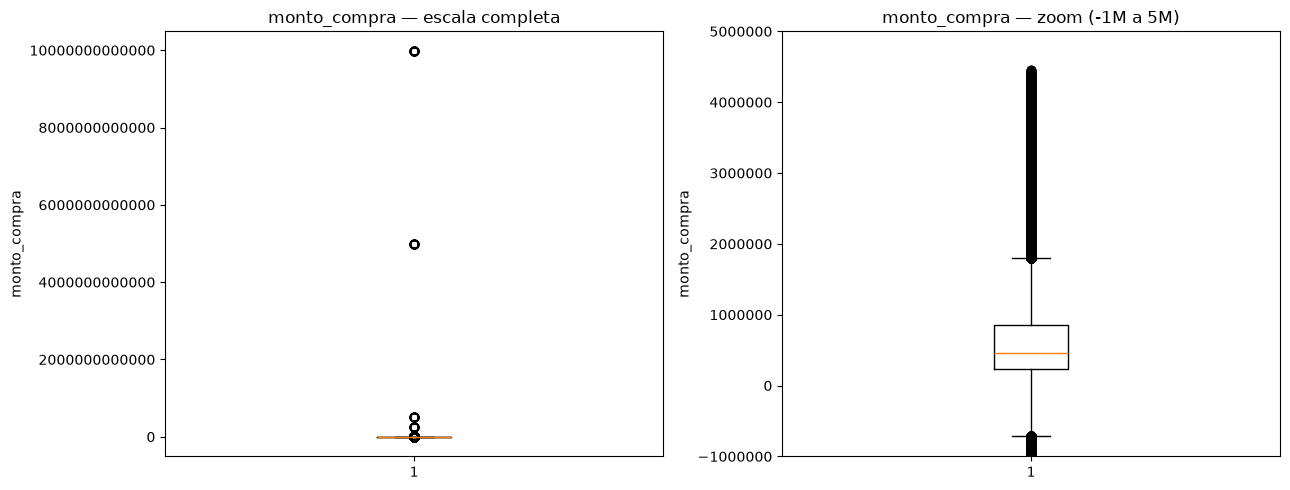

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].boxplot(df['monto_compra'], vert=True)
axes[0].set_title('monto_compra — escala completa')
axes[0].set_ylabel('monto_compra')
axes[0].ticklabel_format(style='plain', axis='y')

axes[1].boxplot(df['monto_compra'], vert=True)
axes[1].set_ylim(-1_000_000, 5_000_000)
axes[1].set_title('monto_compra — zoom (-1M a 5M)')
axes[1].set_ylabel('monto_compra')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

En la escala completa, la caja de monto_compra se ve como una línea plana pegada a cero: los valores centinela (miles de millones) están tan lejos que aplastan todo lo demás en el gráfico. Al hacer zoom entre -1M y 5M sí se ve una caja razonable, con bigotes y algunos puntos por fuera — esos son los atípicos "de verdad", en un rango que al menos es físicamente posible para una compra.

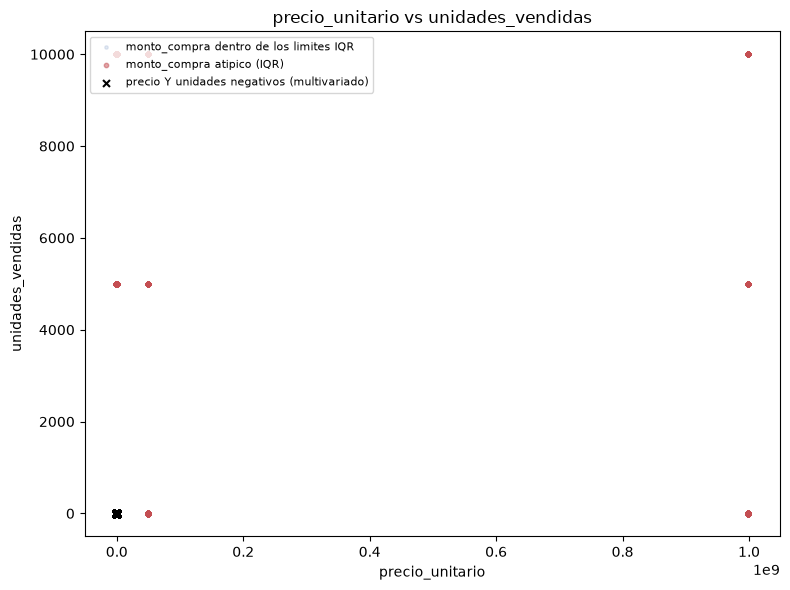

Filas con precio_unitario Y unidades_vendidas negativos a la vez: 532
Ejemplo:


,precio_unitario,unidades_vendidas,monto_compra
498,-202500.0,-3,607500.0
1145,-324700.0,-3,974100.0
2793,-293500.0,-1,293500.0
3158,-192300.0,-1,192300.0
5141,-265900.0,-3,797700.0


In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

normales = ~atipicos_iqr
ax.scatter(df.loc[normales, 'precio_unitario'], df.loc[normales, 'unidades_vendidas'],
           s=6, alpha=0.15, color='#4C72B0', label='monto_compra dentro de los limites IQR')
ax.scatter(df.loc[atipicos_iqr, 'precio_unitario'], df.loc[atipicos_iqr, 'unidades_vendidas'],
           s=10, alpha=0.5, color='#C44E52', label='monto_compra atipico (IQR)')

doble_signo = (df['precio_unitario'] < 0) & (df['unidades_vendidas'] < 0)
ax.scatter(df.loc[doble_signo, 'precio_unitario'], df.loc[doble_signo, 'unidades_vendidas'],
           s=25, color='black', marker='x', label='precio Y unidades negativos (multivariado)')

ax.set_xlabel('precio_unitario')
ax.set_ylabel('unidades_vendidas')
ax.set_title('precio_unitario vs unidades_vendidas')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Filas con precio_unitario Y unidades_vendidas negativos a la vez: {doble_signo.sum():,}")
print("Ejemplo:")
df.loc[doble_signo, ['precio_unitario', 'unidades_vendidas', 'monto_compra']].head()

El scatter confirma tres nubes de puntos bien separadas de la nube "normal": una columna vertical en precios centinela, una fila horizontal en cantidades centinela, y un grupo pegado al origen en el cuadrante negativo-negativo. Ese último es el caso más interesante: son **532 filas con precio_unitario y unidades_vendidas negativos al mismo tiempo**, que al multiplicarse dan un monto_compra positivo y de apariencia normal (ejemplo: -202,500 × -3 = 607,500). Ninguna prueba univariada sobre monto_compra — ni IQR ni z-score — puede atrapar esto, porque el resultado final no tiene nada de raro por sí solo. Solo se ve mirando precio_unitario y unidades_vendidas juntos: es un atípico multivariado.

## Paso 4 — Documentar cada grupo de atípicos antes de decidir

Antes de tratar nada, defino y cuento cada grupo por separado.

In [6]:
sentinel_unidades = [-3, -1, 0, 5000, 9999]
sentinel_precio = [50_000_000.0, 999_000_000.0]

grupo_negativo = df['monto_compra'] < 0
grupo_precio_centinela = df['precio_unitario'].isin(sentinel_precio)
grupo_unidades_centinela = df['unidades_vendidas'].isin(sentinel_unidades)

print(f"Grupo 1 - monto_compra negativo: {grupo_negativo.sum():,}")
print(f"Grupo 2 - precio_unitario centinela (50,000,000 o 999,000,000): {grupo_precio_centinela.sum():,}")
print(f"  valores unicos encontrados: {sorted(df.loc[grupo_precio_centinela, 'precio_unitario'].unique())}")
print(f"Grupo 3 - unidades_vendidas centinela (0, 5000, 9999, -1, -3): {grupo_unidades_centinela.sum():,}")
print(f"  valores unicos encontrados: {sorted(df.loc[grupo_unidades_centinela, 'unidades_vendidas'].unique())}")
print(f"  de los cuales tambien con precio_unitario negativo (atipico multivariado, dentro del Grupo 3): {doble_signo.sum():,}")

hueco = ((df['unidades_vendidas'] > 5) & (df['unidades_vendidas'] < 5000)).sum()
print(f"\nFilas con unidades_vendidas entre 6 y 4999 (si fuera una cola real de pedidos grandes, deberia haber): {hueco:,}")

precio_natural_max = df.loc[(df['precio_unitario'] > 0) & (df['precio_unitario'] < 1_000_000), 'precio_unitario'].max()
print(f"Precio unitario natural mas alto, fuera de los dos valores centinela: {precio_natural_max:,.0f}")

Grupo 1 - monto_compra negativo: 35,650
Grupo 2 - precio_unitario centinela (50,000,000 o 999,000,000): 6,000
  valores unicos encontrados: [np.float64(50000000.0), np.float64(999000000.0)]
Grupo 3 - unidades_vendidas centinela (0, 5000, 9999, -1, -3): 45,000
  valores unicos encontrados: [np.int64(-3), np.int64(-1), np.int64(0), np.int64(5000), np.int64(9999)]
  de los cuales tambien con precio_unitario negativo (atipico multivariado, dentro del Grupo 3): 532

Filas con unidades_vendidas entre 6 y 4999 (si fuera una cola real de pedidos grandes, deberia haber): 0
Precio unitario natural mas alto, fuera de los dos valores centinela: 899,600


**Decisión y justificación de negocio, grupo por grupo:**

- **Grupo 1 — monto_compra negativo.** Una compra no puede tener un monto negativo; es matemáticamente imposible que un cliente pague menos que \$0 por un pedido. No es un valor "extremo pero real", es un valor inválido. **Decisión: eliminar.**
- **Grupo 2 — precio_unitario centinela.** Solo aparecen dos valores exactos, 50,000,000 y 999,000,000, con un salto abrupto: el precio natural más alto en el resto del catálogo no llega ni a 900,000. Ningún producto de Moda, Electrónica, Juguetería, Deportes, Hogar o Belleza de NovaMarket cuesta 50 o 999 millones de pesos; son códigos de error o placeholders de sistema, no precios reales. **Decisión: eliminar.**
- **Grupo 3 — unidades_vendidas centinela.** Los valores 0, -1, -3, 5000 y 9999 se repiten miles de veces de forma exacta, y no hay ni una sola fila con una cantidad entre 6 y 4999 — si 5000 y 9999 fueran pedidos corporativos reales, esperaría ver también 200, 800, 1500 unidades, no solo esos dos números redondos. Es el mismo patrón de códigos de error que el Grupo 2. Dentro de este grupo está además el caso multivariado de las 532 filas con precio y cantidad negativos a la vez, que sin este chequeo se habrían colado como ventas normales. **Decisión: eliminar.**
- **Grupos legítimos.** Después de sacar los tres grupos anteriores, reviso qué atípicos de monto_compra siguen quedando — esos si pueden ser compras grandes reales, y los trato en el Paso 6.

## Paso 5 — Eliminar los errores de captura

In [7]:
mascara_error = grupo_negativo | grupo_precio_centinela | grupo_unidades_centinela
print(f"Filas marcadas como error de captura: {mascara_error.sum():,} ({mascara_error.sum()/N*100:.2f}%)")

df_tratado = df[~mascara_error].copy().reset_index(drop=True)
print(f"Filas antes de tratar: {N:,}")
print(f"Filas despues de eliminar errores de captura: {len(df_tratado):,}")

Filas marcadas como error de captura: 68,210 (11.00%)


Filas antes de tratar: 620,000
Filas despues de eliminar errores de captura: 551,790


## Paso 6 — Recalcular límites sobre los datos ya sin errores, y decidir qué hacer con lo que sigue por fuera

Con los errores de captura fuera, vuelvo a calcular Q1, Q3 y los límites del IQR sobre monto_compra. Lo que siga por encima del nuevo limite_superior ya no puede ser un código de error (esos ya salieron); reviso unidades_vendidas de esas filas para decidir si son compras grandes creíbles o no.

In [8]:
Q1_t = df_tratado['monto_compra'].quantile(0.25)
Q3_t = df_tratado['monto_compra'].quantile(0.75)
IQR_t = Q3_t - Q1_t
limite_inferior_t = Q1_t - 1.5 * IQR_t
limite_superior_t = Q3_t + 1.5 * IQR_t

print(f"Q1 = {Q1_t:,.0f}   Q3 = {Q3_t:,.0f}   IQR = {IQR_t:,.0f}")
print(f"limite_inferior = {limite_inferior_t:,.0f}")
print(f"limite_superior = {limite_superior_t:,.0f}")

restantes = df_tratado[df_tratado['monto_compra'] > limite_superior_t]
print(f"\nFilas que siguen por encima del limite superior: {len(restantes):,}")
print("\nunidades_vendidas de esas filas:")
print(restantes['unidades_vendidas'].value_counts().sort_index())

Q1 = 268,600   Q3 = 829,000   IQR = 560,400
limite_inferior = -572,000
limite_superior = 1,669,600

Filas que siguen por encima del limite superior: 37,552

unidades_vendidas de esas filas:
unidades_vendidas
2      840
3    11891
4    12511
5    12310
Name: count, dtype: int64


Los que quedan se reparten en unidades_vendidas entre 2 y 5 — todos dentro del rango normal de un pedido de retail, combinados con un precio_unitario en la parte alta pero natural del catálogo (nada de códigos). Decido separarlos en dos grupos según qué tan fuerte es la evidencia de que es una compra grande deliberada y no una coincidencia estadística:

- **unidades_vendidas en {4, 5}** — el máximo real de unidades que se compra en un pedido normal (recordar: no hay nada entre 6 y 4999). Varias unidades de un producto en la parte alta del precio catalogado es exactamente lo que se ve en un pedido grande legítimo, posiblemente de un cliente que compra para revender o para un evento. **Decisión: mantener, documentar y marcar como venta de alto valor (es_venta_corporativa).**
- **unidades_vendidas en {2, 3}** — la evidencia de "compra grande deliberada" es más débil (son pocas unidades); lo más probable es que sea la cola natural de precios altos combinada con el ruido normal del negocio, no un patrón de negocio claro. Como no tengo una justificación de negocio tan fuerte para conservarlos intactos, prefiero no borrarlos (siguen siendo compras posibles) pero sí limitar su influencia en la media y la desviación estándar. **Decisión: capar (winsorizing) al limite_superior.**

In [9]:
es_corporativa = (df_tratado['monto_compra'] > limite_superior_t) & (df_tratado['unidades_vendidas'].isin([4, 5]))
a_capar = (df_tratado['monto_compra'] > limite_superior_t) & (df_tratado['unidades_vendidas'].isin([2, 3]))

print(f"Filas a mantener y marcar como venta de alto valor: {es_corporativa.sum():,}")
print(f"Filas a capar (winsorizing): {a_capar.sum():,}")

df_tratado['es_venta_corporativa'] = es_corporativa

media_antes = df_tratado.loc[a_capar, 'monto_compra'].mean()
std_antes = df_tratado['monto_compra'].std()

df_tratado['monto_compra_capado'] = False
df_tratado.loc[a_capar, 'monto_compra'] = df_tratado.loc[a_capar, 'monto_compra'].clip(upper=limite_superior_t)
df_tratado.loc[a_capar, 'monto_compra_capado'] = True

media_despues = df_tratado.loc[a_capar, 'monto_compra'].mean()
std_despues = df_tratado['monto_compra'].std()

print(f"\nGrupo capado — media de monto_compra antes: {media_antes:,.0f}  |  despues: {media_despues:,.0f}")
print(f"monto_compra (dataset completo) — desviacion estandar antes: {std_antes:,.0f}  |  despues: {std_despues:,.0f}")

Filas a mantener y marcar como venta de alto valor: 24,821
Filas a capar (winsorizing): 12,731

Grupo capado — media de monto_compra antes: 1,994,209  |  despues: 1,669,600
monto_compra (dataset completo) — desviacion estandar antes: 590,788  |  despues: 574,462


La media del grupo capado bajó (se les quitó exactamente el exceso por encima del límite superior) y la desviación estándar de todo monto_compra también bajó, de forma coherente con haber reducido los valores más extremos que quedaban. Las filas marcadas es_venta_corporativa=True no las tocó el clip() — se conservan con su valor original, documentadas.

## Paso 7 — Verificación final de límites

In [10]:
excede_limite = df_tratado['monto_compra'] > limite_superior_t
excede_no_documentado = excede_limite & ~df_tratado['es_venta_corporativa']

print(f"Filas que superan limite_superior: {excede_limite.sum():,}")
print(f"  - de las cuales documentadas como venta de alto valor (es_venta_corporativa=True): {(excede_limite & df_tratado['es_venta_corporativa']).sum():,}")
print(f"  - de las cuales sin documentar (no deberia haber ninguna): {excede_no_documentado.sum():,}")

assert excede_no_documentado.sum() == 0, "Quedaron atipicos por encima del limite sin capar ni documentar"
print("\nOK: monto_compra ya no supera el limite superior, salvo los casos conservados a proposito.")

Filas que superan limite_superior: 24,821
  - de las cuales documentadas como venta de alto valor (es_venta_corporativa=True): 24,821
  - de las cuales sin documentar (no deberia haber ninguna): 0

OK: monto_compra ya no supera el limite superior, salvo los casos conservados a proposito.


## Paso 8 — Serie diaria de ventas y media móvil

Agrupo monto_compra por día (sobre los datos ya tratados) y aplico una media móvil de 7 días para suavizar el ruido diario.

Dias con datos: 836  (2025-01-01 a 2027-12-28)
Desviacion estandar de la serie diaria cruda: 318,732,836
Desviacion estandar de la media movil de 7 dias: 317,083,202


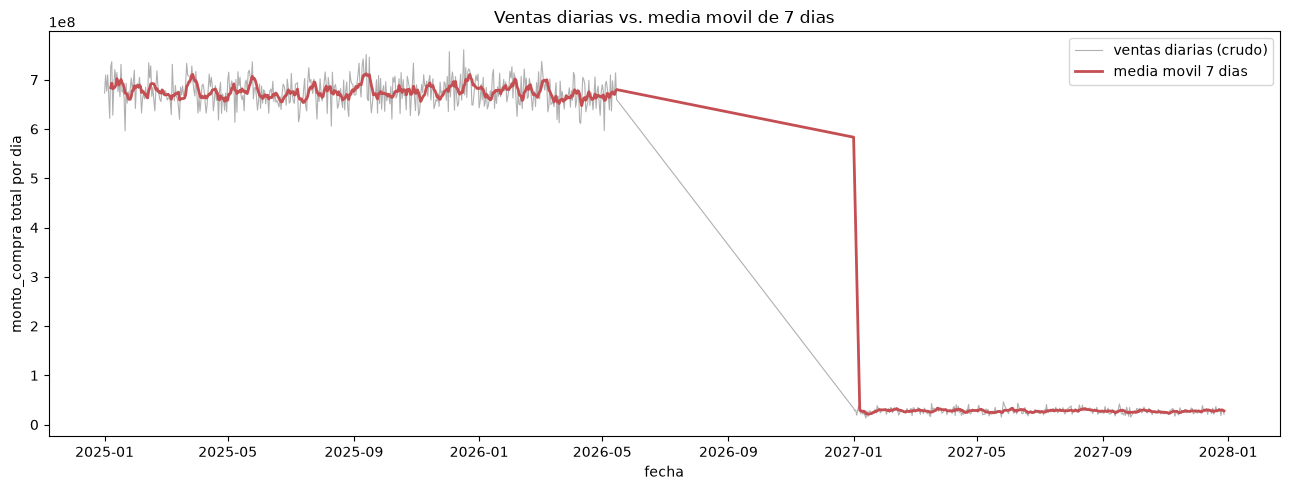

In [11]:
serie_diaria = (df_tratado.dropna(subset=['fecha_pedido'])
                .groupby(df_tratado['fecha_pedido'].dt.date)['monto_compra']
                .sum())
serie_diaria.index = pd.to_datetime(serie_diaria.index)
media_movil_7d = serie_diaria.rolling(7).mean()

print(f"Dias con datos: {len(serie_diaria):,}  ({serie_diaria.index.min().date()} a {serie_diaria.index.max().date()})")
print(f"Desviacion estandar de la serie diaria cruda: {serie_diaria.std():,.0f}")
print(f"Desviacion estandar de la media movil de 7 dias: {media_movil_7d.std():,.0f}")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_diaria.index, serie_diaria.values, color='#B0B0B0', linewidth=0.8, label='ventas diarias (crudo)')
ax.plot(media_movil_7d.index, media_movil_7d.values, color='#C44E52', linewidth=2, label='media movil 7 dias')
ax.set_xlabel('fecha')
ax.set_ylabel('monto_compra total por dia')
ax.set_title('Ventas diarias vs. media movil de 7 dias')
ax.legend()
plt.tight_layout()
plt.show()

La serie cruda es una nube de vaivén día a día que, a simple vista, se parece a puro ruido. La media móvil de 7 días deja ver algo que en la serie cruda no se distinguía con claridad: **hay dos niveles muy distintos, no ruido dentro de un solo nivel**. Entre el 1 de enero de 2025 y el 15 de mayo de 2026 las ventas diarias se mantienen estables alrededor de \$680–690 millones (con el vaivén normal encima). Después hay un salto — no un par de días raros, sino un cambio sostenido — a un nivel muchísimo más bajo, cerca de \$28 millones diarios, durante todo 2027. La media móvil confirma que ese cambio de nivel es real y sostenido en el tiempo, y no un efecto de dos o tres días con datos raros.

## Paso 9 — Exportar el dataset final

In [12]:
df_tratado.to_csv('S07_PD_Pallares_DatasetSinOutliers.csv', index=False)
print(f"Dataset exportado: S07_PD_Pallares_DatasetSinOutliers.csv ({len(df_tratado):,} filas, {df_tratado.shape[1]} columnas)")

verificacion = pd.read_csv('S07_PD_Pallares_DatasetSinOutliers.csv')
excede_verificacion = (verificacion['monto_compra'] > limite_superior_t) & ~verificacion['es_venta_corporativa']
print(f"\nFilas en el archivo exportado que superan limite_superior sin documentar: {excede_verificacion.sum()} (esperado: 0)")
print(f"es_venta_corporativa=True en el archivo exportado: {verificacion['es_venta_corporativa'].sum():,}")
print(f"monto_compra_capado=True en el archivo exportado: {verificacion['monto_compra_capado'].sum():,}")

Dataset exportado: S07_PD_Pallares_DatasetSinOutliers.csv (551,790 filas, 27 columnas)



Filas en el archivo exportado que superan limite_superior sin documentar: 0 (esperado: 0)
es_venta_corporativa=True en el archivo exportado: 24,821
monto_compra_capado=True en el archivo exportado: 12,731


## Conclusión

Sobre las 620,000 filas de S06_PD_Pallares_DatasetDepurado.csv:

- El IQR marcó 66,306 filas atípicas en monto_compra; el z-score, con la desviación estándar disparada por los valores extremos, solo marcó 123 — el z-score no es confiable en un dataset con atípicos tan extremos.
- 68,210 filas eran errores de captura (montos negativos, precios centinela de 50 y 999 millones, cantidades centinela como 5000, 9999, -1 y -3), incluyendo 532 filas con un atípico multivariado camuflado (precio y cantidad negativos a la vez, que al multiplicarse parecían un monto normal). Esas se eliminaron.
- De lo que quedó fuera de los límites después de limpiar los errores, las compras de 4-5 unidades a precio alto se mantuvieron y se documentaron como venta de alto valor (es_venta_corporativa); las de 2-3 unidades se caparon con clip() (monto_compra_capado).
- La media móvil de 7 días sobre la serie diaria dejó ver un cambio de nivel real entre el período 2025–mayo 2026 y el año 2027, que en la serie cruda se confundía con ruido.

S07_PD_Pallares_DatasetSinOutliers.csv queda listo para escalado, codificación y transformaciones.